## Loading Data

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("TSLA.csv")

In [3]:
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,10/15/2018,17.270666,17.552000,16.969334,17.306000,17.306000,93000000
1,10/16/2018,17.713333,18.492001,17.482668,18.439333,18.439333,142896000
2,10/17/2018,18.826668,18.846666,17.719999,18.118668,18.118668,129832500
3,10/18/2018,17.952667,18.066668,17.533333,17.594000,17.594000,81318000
4,10/19/2018,17.826000,17.977333,16.900000,17.333332,17.333332,140632500
...,...,...,...,...,...,...,...
1253,10/9/2023,255.309998,261.359985,252.050003,259.670013,259.670013,101377900
1254,10/10/2023,257.750000,268.940002,257.649994,263.619995,263.619995,122656000
1255,10/11/2023,266.200012,268.600006,260.899994,262.989990,262.989990,103706300
1256,10/12/2023,262.920013,265.410004,256.630005,258.869995,258.869995,111508100


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1258 non-null   object 
 1   Open       1258 non-null   float64
 2   High       1258 non-null   float64
 3   Low        1258 non-null   float64
 4   Close      1258 non-null   float64
 5   Adj Close  1258 non-null   float64
 6   Volume     1258 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 68.9+ KB


In [5]:
data['Date'] = pd.to_datetime(data['Date'])  # Convert 'Date' column to datetime format
data.set_index('Date', inplace=True)  # Set 'Date' as the DataFrame index

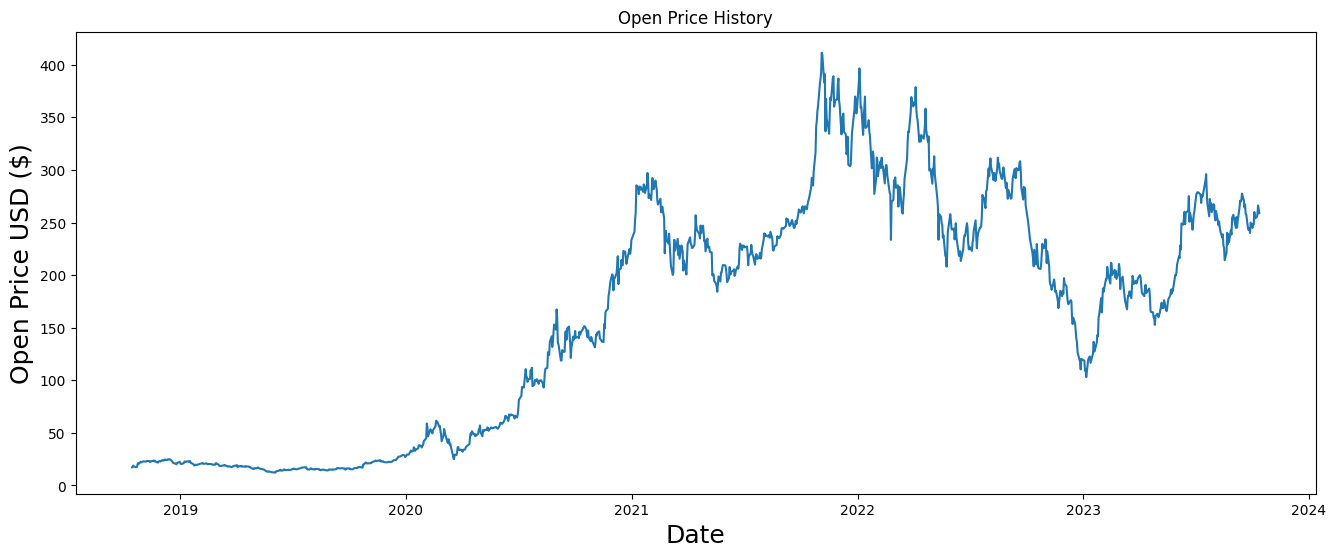

In [6]:
plt.figure(figsize=(16,6))
plt.title('Open Price History')
plt.plot(data['Open'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Open Price USD ($)', fontsize=18)
plt.show()


# Spliting Data as Train and Validation

In [7]:
length_data = len(data)     # rows that data has
split_ratio = 0.7           # %70 train + %30 validation
length_train = round(length_data * split_ratio)
length_validation = length_data - length_train
print("Data length :", length_data)
print("Train data length :", length_train)
print("Validation data lenth :", length_validation)

Data length : 1258
Train data length : 881
Validation data lenth : 377


In [10]:
print(data.columns.tolist())

['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [11]:
train_data = data[:length_train].iloc[:,:2]
#train_data['Date'] = pd.to_datetime(train_data['Date'])  # converting to date time object
train_data

,Open,High
Date,,
2018-10-15,17.270666,17.552000
2018-10-16,17.713333,18.492001
2018-10-17,18.826668,18.846666
2018-10-18,17.952667,18.066668
2018-10-19,17.826000,17.977333
...,...,...
2022-04-07,350.796661,358.863342
2022-04-08,347.736664,349.480011
2022-04-11,326.799988,336.156677


In [13]:
validation_data = data[length_train:].iloc[:,:2]
#validation_data['Date'] = pd.to_datetime(validation_data['Date'])  # converting to date time object
validation_data

,Open,High
Date,,
2022-04-14,333.096680,337.570007
2022-04-18,329.676666,338.306671
2022-04-19,335.019989,344.980011
2022-04-20,343.333344,344.666656
2022-04-21,358.243347,364.073334
...,...,...
2023-10-09,255.309998,261.359985
2023-10-10,257.750000,268.940002
2023-10-11,266.200012,268.600006


## Creating Train Dataset from Train split

In [14]:
dataset_train = train_data.Open.values
dataset_train.shape

(881,)

In [15]:
# Change 1d array to 2d array
dataset_train = np.reshape(dataset_train, (-1,1))
dataset_train.shape

(881, 1)

## Normalization / Feature Scaling

In [16]:
#Dataset values will be in between 0 and 1 after scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))


# scaling dataset
dataset_train_scaled = scaler.fit_transform(dataset_train)

dataset_train_scaled.shape

(881, 1)

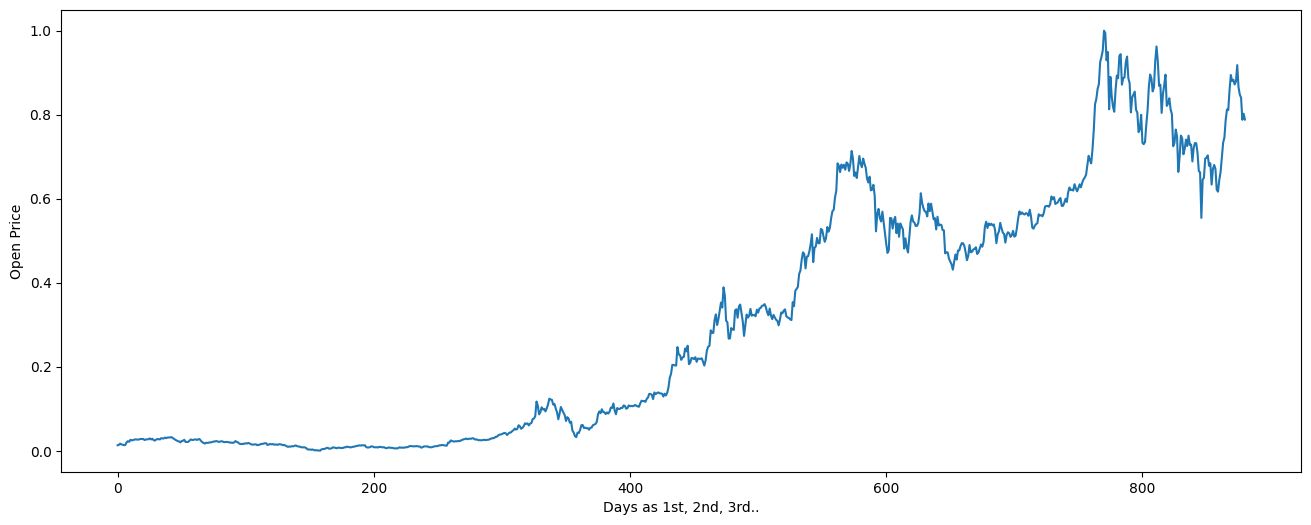

In [17]:
plt.subplots(figsize = (16,6))
plt.plot(dataset_train_scaled)
plt.xlabel("Days as 1st, 2nd, 3rd..")
plt.ylabel("Open Price")
plt.show()

## Creating X_train and y_train from Train data



In [18]:
X_train = []
y_train = []

time_step = 50

for i in range(time_step, length_train):
    X_train.append(dataset_train_scaled[i-time_step:i,0])
    y_train.append(dataset_train_scaled[i,0])

# convert list to array
X_train, y_train = np.array(X_train), np.array(y_train)

In [19]:
print("Shape of X_train before reshape :",X_train.shape)
print("Shape of y_train before reshape :",y_train.shape)

Shape of X_train before reshape : (831, 50)
Shape of y_train before reshape : (831,)


## Reshape

In [20]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],1))
y_train = np.reshape(y_train, (y_train.shape[0],1))

print("Shape of X_train after reshape :",X_train.shape)
print("Shape of y_train after reshape :",y_train.shape)

Shape of X_train after reshape : (831, 50, 1)
Shape of y_train after reshape : (831, 1)


Shape of X_train :831 x 50 x 1

That means we have 831 rows, each row has 50 rows and 1 column

Lets check the first row: it has 50 rows (open prices of 49 days)

In [21]:
X_train[0]

array([[0.01301296],
       [0.0141213 ],
       [0.01690884],
       [0.01472054],
       [0.01440339],
       [0.01328337],
       [0.01381584],
       [0.02002187],
       [0.02272094],
       [0.02122368],
       [0.02610103],
       [0.02458542],
       [0.02527813],
       [0.0262329 ],
       [0.02714762],
       [0.0266068 ],
       [0.02636811],
       [0.02708085],
       [0.02794215],
       [0.0280256 ],
       [0.02792045],
       [0.02538162],
       [0.02697402],
       [0.02691226],
       [0.02738965],
       [0.02925079],
       [0.02681545],
       [0.02852636],
       [0.02558025],
       [0.02401957],
       [0.02653169],
       [0.02752318],
       [0.02769177],
       [0.0268288 ],
       [0.02986171],
       [0.02920238],
       [0.0291957 ],
       [0.03136397],
       [0.02986171],
       [0.03151587],
       [0.03143408],
       [0.03155593],
       [0.03236549],
       [0.03019554],
       [0.02828266],
       [0.02612273],
       [0.02436175],
       [0.022

Check the first item in y_train
It is the price of 50th day

In [22]:
y_train[0]

array([0.02315826])

Creating RNN model

In [23]:
# importing libraries
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import SimpleRNN
from keras.layers import Dropout

# initializing the RNN
regressor = Sequential()

# adding first RNN layer and dropout regulatization
regressor.add(
    SimpleRNN(units = 50,
              activation = "tanh",
              return_sequences = True,
              input_shape = (X_train.shape[1],1))
             )

regressor.add(
    Dropout(0.2)
             )


# adding second RNN layer and dropout regulatization

regressor.add(
    SimpleRNN(units = 50,
              activation = "tanh",
              return_sequences = True)
             )

regressor.add(
    Dropout(0.2)
             )

# adding third RNN layer and dropout regulatization

regressor.add(
    SimpleRNN(units = 50,
              activation = "tanh",
              return_sequences = True)
             )

regressor.add(
    Dropout(0.2)
             )

# adding fourth RNN layer and dropout regulatization

regressor.add(
    SimpleRNN(units = 50)
             )

regressor.add(
    Dropout(0.2)
             )

# adding the output layer
regressor.add(Dense(units = 1))

# compiling RNN
regressor.compile(
    optimizer = "adam",
    loss = "mean_squared_error",
    metrics = ["accuracy"])

# fitting the RNN
history = regressor.fit(X_train, y_train, epochs = 50, batch_size = 32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.0012 - loss: 0.4139
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.0012 - loss: 0.2989    
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.0012 - loss: 0.2139    
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.0024 - loss: 0.1809
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.0012 - loss: 0.1441    
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.0024 - loss: 0.1121
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.0024 - loss: 0.0972
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.0024 - loss: 0.0728
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.0012 - loss: 0.0605    
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.0024 - loss: 0.0527
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.0024 - loss: 0.0444    
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 4

## Evaluating Model

In [24]:
# Losses
history.history["loss"]

[0.4138803482055664,
 0.29888367652893066,
 0.21391405165195465,
 0.1808711439371109,
 0.1440541297197342,
 0.1121249720454216,
 0.09722757339477539,
 0.07279506325721741,
 0.06054457649588585,
 0.05267283320426941,
 0.04437245428562164,
 0.04770536348223686,
 0.04383482038974762,
 0.037797339260578156,
 0.031845808029174805,
 0.03181885555386543,
 0.026075461879372597,
 0.026791715994477272,
 0.02290036901831627,
 0.02161993272602558,
 0.023045307025313377,
 0.020237386226654053,
 0.019773274660110474,
 0.017714228481054306,
 0.017753511667251587,
 0.02183973789215088,
 0.013686510734260082,
 0.015280003659427166,
 0.013058786280453205,
 0.01248975470662117,
 0.012484756298363209,
 0.01215625274926424,
 0.011321303434669971,
 0.010231777094304562,
 0.009505974128842354,
 0.010517844930291176,
 0.010020137764513493,
 0.009689108468592167,
 0.009706458076834679,
 0.00959697738289833,
 0.009137873537838459,
 0.008453219197690487,
 0.008250240236520767,
 0.0071847103536129,
 0.00784312281

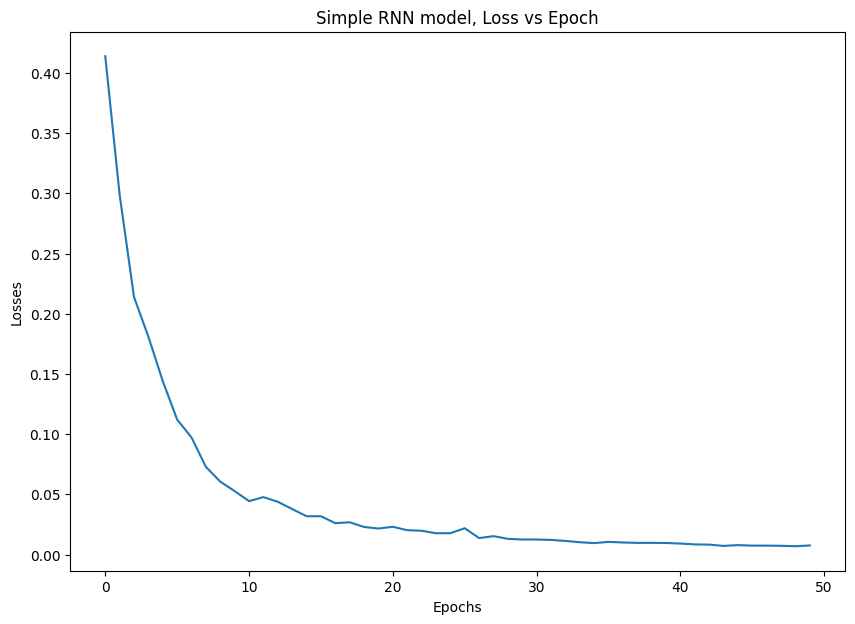

In [25]:
# Plotting Loss vs Epochs
plt.figure(figsize =(10,7))
plt.plot(history.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.title("Simple RNN model, Loss vs Epoch")
plt.show()

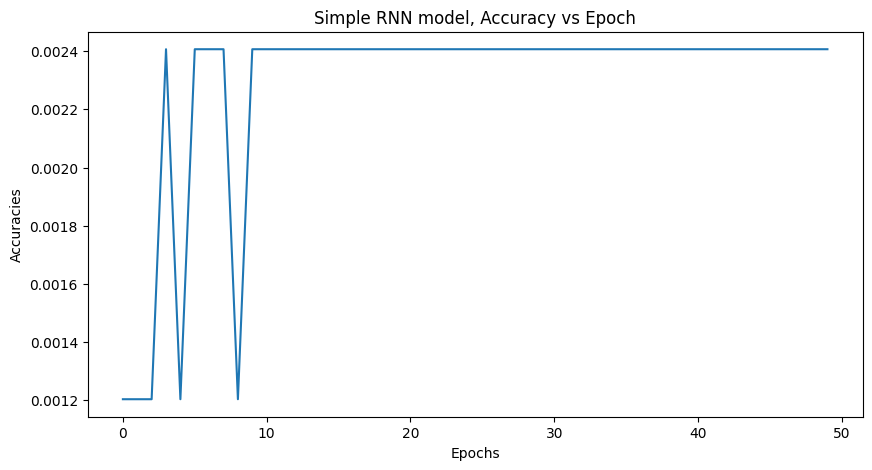

In [26]:
# Plotting Accuracy vs Epochs
plt.figure(figsize =(10,5))
plt.plot(history.history["accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracies")
plt.title("Simple RNN model, Accuracy vs Epoch")
plt.show()

## Model predictions for train data

In [27]:
y_pred = regressor.predict(X_train)  # predictions
y_pred = scaler.inverse_transform(y_pred) # scaling back from 0-1 to original
y_pred.shape

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


(831, 1)

In [28]:
y_train = scaler.inverse_transform(y_train) # scaling back from 0-1 to original
y_train.shape

(831, 1)

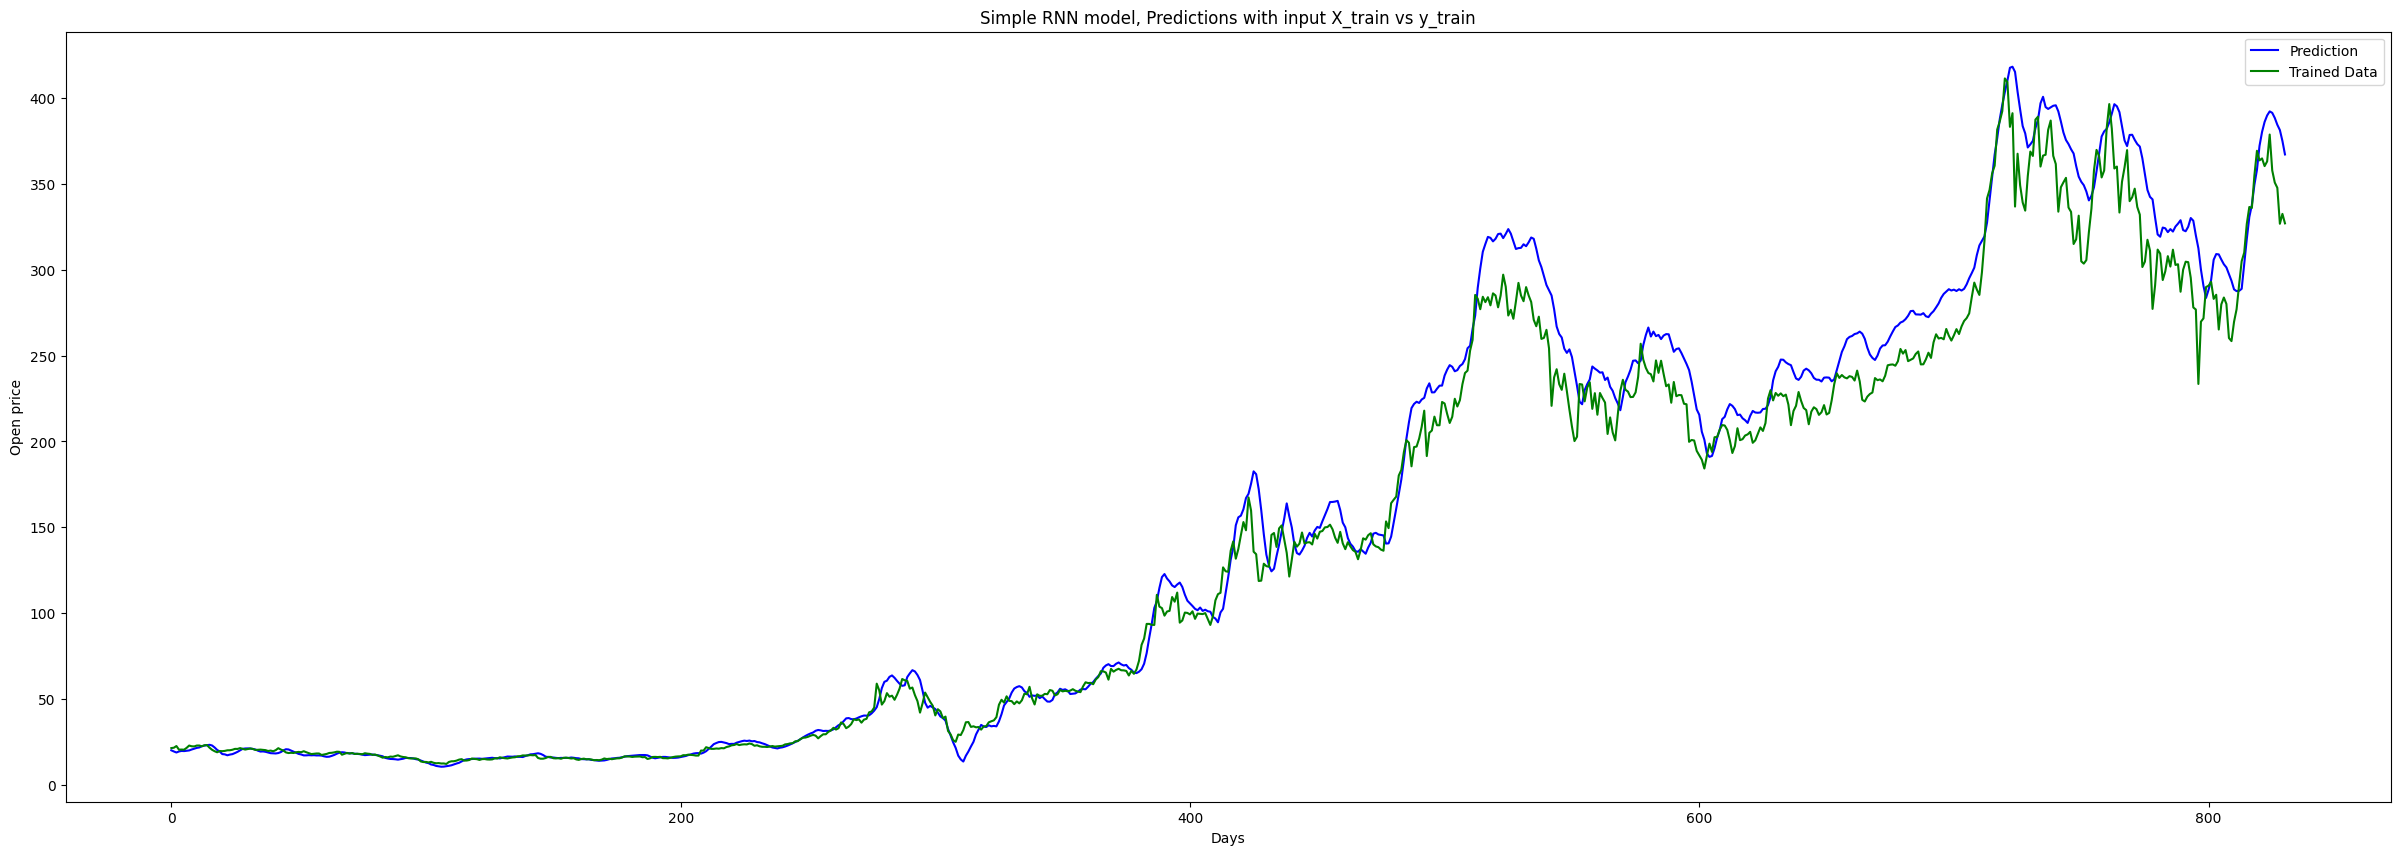

In [29]:
# visualisation
plt.figure(figsize = (30,10))
plt.plot(y_pred, color = "b", label = "Prediction" )
plt.plot(y_train, color = "g", label = "Trained Data")
plt.xlabel("Days")
plt.ylabel("Open price")
plt.title("Simple RNN model, Predictions with input X_train vs y_train")
plt.legend()
plt.show()


## Creating Test Dataset from Validation Data

Converting array and scaling

In [30]:
dataset_validation = validation_data.Open.values  # getting "open" column and converting to array
dataset_validation = np.reshape(dataset_validation, (-1,1))  # converting 1D to 2D array
scaled_dataset_validation =  scaler.fit_transform(dataset_validation)  # scaling open values to between 0 and 1
print("Shape of scaled validation dataset :",scaled_dataset_validation.shape)

Shape of scaled validation dataset : (377, 1)


 Creating X_test and y_test

In [31]:
# Creating X_test and y_test
X_test = []
y_test = []

for i in range(time_step, length_validation):
    X_test.append(scaled_dataset_validation[i-time_step:i,0])
    y_test.append(scaled_dataset_validation[i,0])

Converting to array

In [32]:
# Converting to array
X_test, y_test = np.array(X_test), np.array(y_test)
print("Shape of X_test before reshape :",X_test.shape)
print("Shape of y_test before reshape :",y_test.shape)

Shape of X_test before reshape : (327, 50)
Shape of y_test before reshape : (327,)


Reshape

In [33]:
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))  # reshape to 3D array
y_test = np.reshape(y_test, (-1,1))  # reshape to 2D array

In [34]:
print("Shape of X_test after reshape :",X_test.shape)
print("Shape of y_test after reshape :",y_test.shape)

Shape of X_test after reshape : (327, 50, 1)
Shape of y_test after reshape : (327, 1)


## Model prediction with Validation Data

In [35]:
# predictions with X_test data
y_pred_of_test = regressor.predict(X_test)
# scaling back from 0-1 to original
y_pred_of_test = scaler.inverse_transform(y_pred_of_test)
print("Shape of y_pred_of_test :",y_pred_of_test.shape)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Shape of y_pred_of_test : (327, 1)


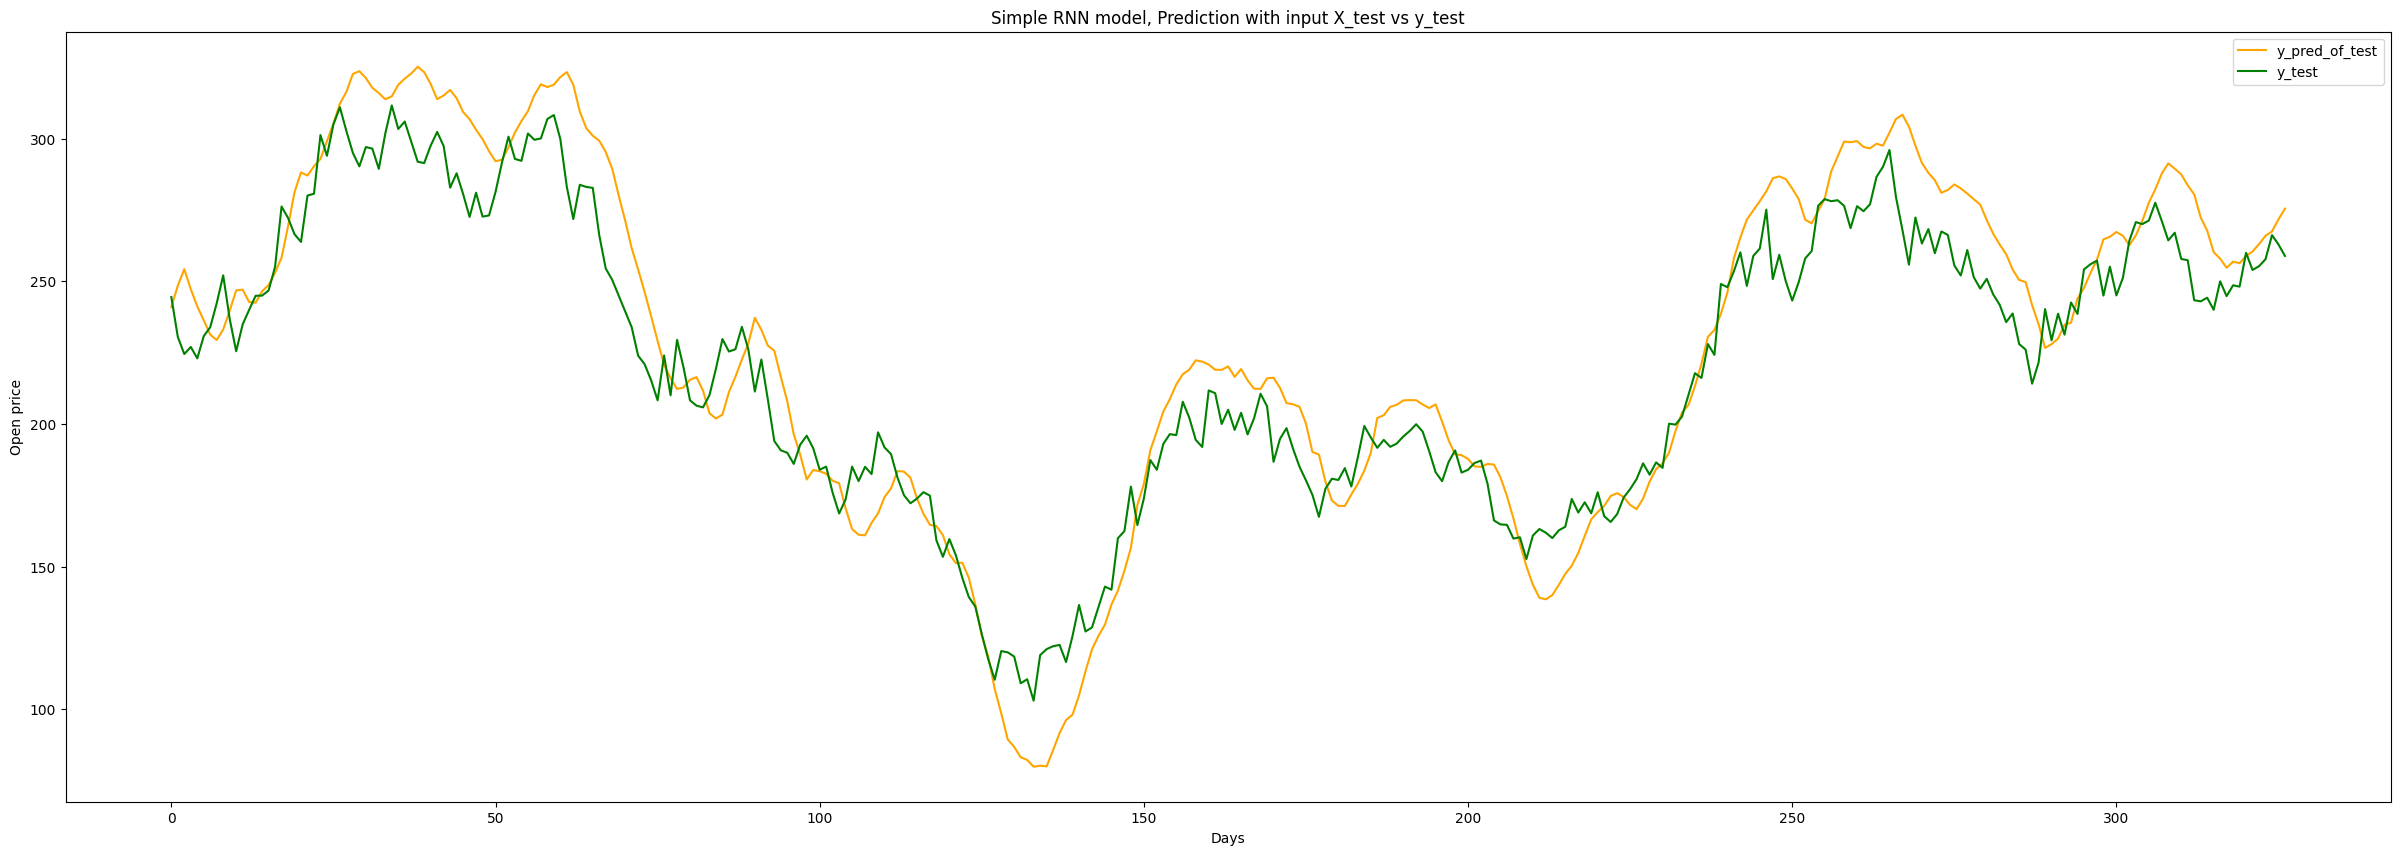

In [36]:
# visualisation
plt.figure(figsize = (30,10))
plt.plot(y_pred_of_test, label = "y_pred_of_test", c = "orange")
plt.plot(scaler.inverse_transform(y_test), label = "y_test", c = "g")
plt.xlabel("Days")
plt.ylabel("Open price")
plt.title("Simple RNN model, Prediction with input X_test vs y_test")
plt.legend()
plt.show()

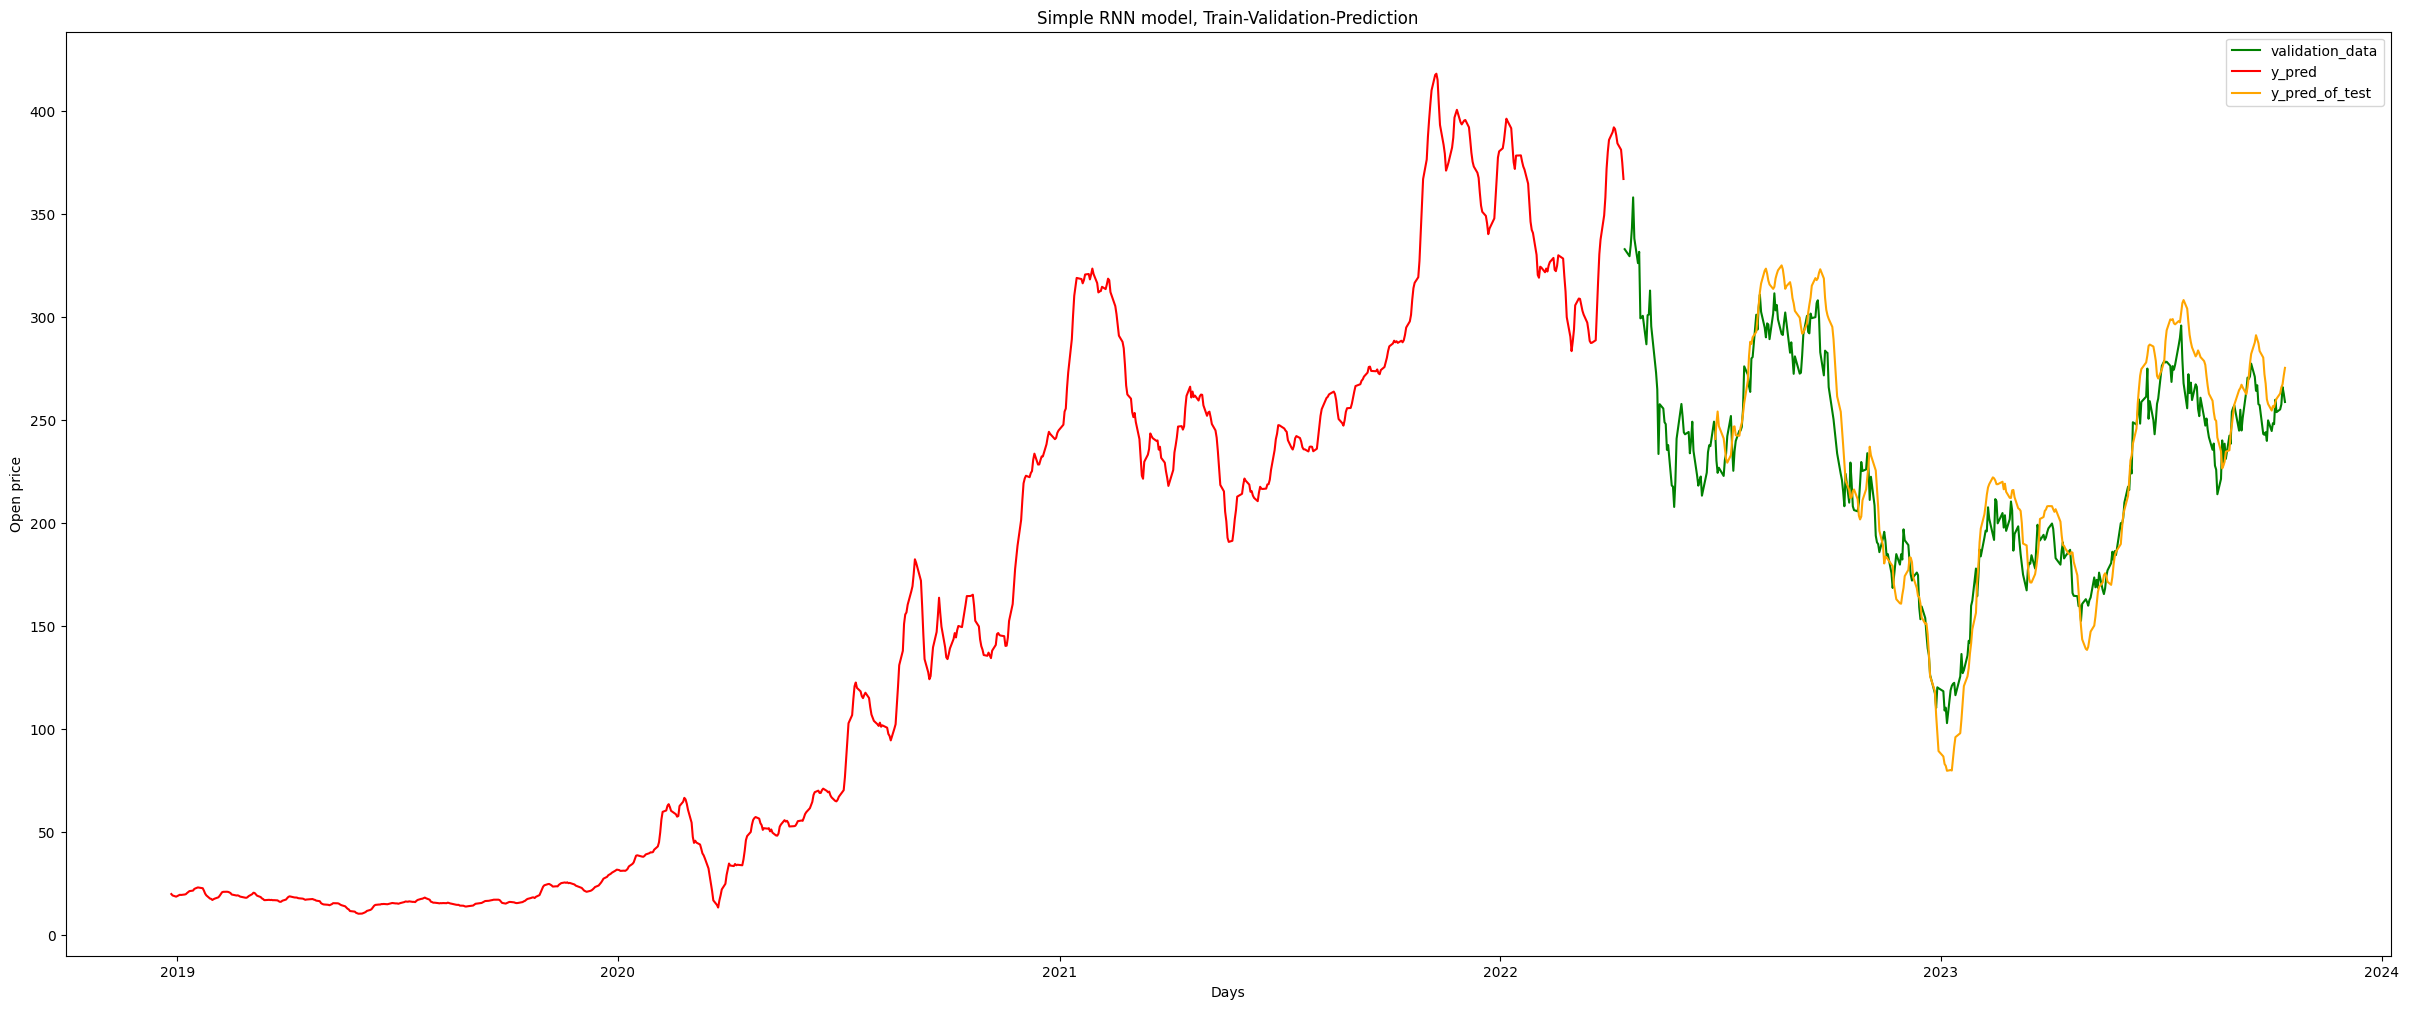

In [39]:
plt.subplots(figsize =(30,12))

plt.plot(validation_data.index, validation_data.Open, label="validation_data", color="g")
plt.plot(train_data.index[time_step:], y_pred, label="y_pred", color="r")
plt.plot(validation_data.index[time_step:], y_pred_of_test, label="y_pred_of_test", color="orange")

plt.xlabel("Days")
plt.ylabel("Open price")
plt.title("Simple RNN model, Train-Validation-Prediction")
plt.legend()
plt.show()